# Credit Risk & Borrower Delinquency Analytics

## Objective
Analyze borrower characteristics from a consumer credit dataset (~150,000 borrowers) and identify which characteristics are associated with serious delinquency (90+ days late) within a two-year window.

## Key Business Question
What borrower characteristics are associated with higher delinquency risk?

## Dataset
Source: Kaggle "Give Me Some Credit" (`cs-training.csv`), 150,000 rows, 12 columns. Target variable: `SeriousDlqin2yrs` (1 = borrower was seriously delinquent within 2 years, 0 = not).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Note:** update the path below to wherever `cs-training.csv` is stored on your machine before running.

In [2]:
df=pd.read_csv(r"D:\Credit Risk Analysis\cs-training.csv")

## 2. First Look at the Data
Basic shape, structure, and how balanced the target variable is, before doing anything else.

In [3]:
df.head(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [4]:
df.shape

(150000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [6]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
(df.isnull().sum()/ len(df))*100

Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

**Insight:** No missing values at first glance for most columns, but `MonthlyIncome` is missing for ~19.8% of borrowers and `NumberOfDependents` is missing for ~2.6%. That's a real gap to handle, not ignore, since income is one of the most obviously relevant fields for a credit risk question.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.duplicated(subset=["Unnamed: 0"]).sum()

np.int64(0)

**Insight:** No fully duplicated rows in the dataset (`df.duplicated().sum()` = 0), 
and no duplicate values in the `Unnamed: 0` index either — confirming each row 
represents one unique borrower record with no re-ingestion or copy-paste errors 
to clean up before proceeding.

In [10]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [11]:
(df["SeriousDlqin2yrs"].value_counts()/ len(df))*100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: count, dtype: float64

**Insight:** The target is heavily imbalanced — only 6.68% of borrowers were seriously delinquent. This matters for the rest of the analysis: the overall average delinquency rate is ~6.7%, so any borrower segment sitting meaningfully above that number is a genuinely higher-risk group, not just noise.

In [12]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 3. Data Quality Investigation
`describe()` above already shows a few numbers that don't make sense for real borrowers (age 0, age 109, values like 96/98 in the past-due columns, debt ratios in the thousands). Before cleaning anything, dig into each one to confirm it's actually a data issue and not a real edge case.

### Age outliers

In [13]:
df[df["age"] == 0].shape

(1, 12)

In [14]:
df[df["age"] == 109].shape

(2, 12)

In [15]:
df[df["age"]==109]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
105790,105791,0,0.109307,109,0,2141.0,NaN,17,0,1,0,NaN
138291,138292,0,0.246529,109,0,318.0,NaN,3,0,0,0,NaN


**Insight:** 1 borrower has age 0 and 2 have age 109 — not plausible values, almost certainly data entry errors. Only 3 rows total, so dropping them costs nothing statistically.

### Past-due columns: the 96 / 98 placeholder codes

In [16]:
df["NumberOfTime30-59DaysPastDueNotWorse"].describe()

count    150000.000000
mean          0.421033
std           4.192781
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

In [17]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

**Insight:** The three "days past due" columns all cap out at realistic single/low-double-digit values, except for two specific numbers — 96 and 98 — which show up identically across all three columns (264 rows with 98, 5 rows with 96). That pattern (same row count, same values, across three unrelated columns) is the signature of a placeholder/error code, not a real count of late payments.

In [18]:
df[df["NumberOfTime30-59DaysPastDueNotWorse"]==98]["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    143
0    121
Name: count, dtype: int64

In [19]:
df[df["NumberOfTime30-59DaysPastDueNotWorse"]==96]["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    4
0    1
Name: count, dtype: int64

**Insight:** Confirms it — the 98-group has a wildly inconsistent delinquency mix (121 non-delinquent vs 143 delinquent) and the 96-group is only 5 rows. Neither looks like a genuine payment history. Treating both as missing (NaN) rather than as real counts.

## 4. Data Cleaning
Based on the investigation above: drop the 3 impossible-age rows, and convert the 96/98 placeholder codes in the past-due columns to NaN (leaving them as real numbers would badly distort any average or model).

In [20]:
df_clean = df.copy()

In [21]:
df_clean= df_clean[(df_clean["age"] !=0)& (df_clean["age"] != 109)]

In [22]:
df_clean["NumberOfTime30-59DaysPastDueNotWorse"] = df_clean["NumberOfTime30-59DaysPastDueNotWorse"].replace({96: np.nan , 98: np.nan})

In [23]:
df_clean["NumberOfTime60-89DaysPastDueNotWorse"]=df_clean["NumberOfTime60-89DaysPastDueNotWorse"].replace({96: np.nan , 98: np.nan})

In [24]:
df_clean["NumberOfTimes90DaysLate"]=df_clean["NumberOfTimes90DaysLate"].replace({96:np.nan , 98: np.nan})

In [25]:
df_clean.shape

(149997, 12)

In [26]:
df_clean.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29729
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3922
dtype: int64

**Insight:** After cleaning, 149,997 rows remain. MonthlyIncome and NumberOfDependents keep their missing values on purpose (per the check above), and the three past-due columns now correctly show 269 missing each — the rows that had placeholder codes.

## 5. Delinquency Rate by Borrower Segment
For each variable, the pattern is: bucket it into readable groups, then compare the delinquency rate across groups against the overall baseline of 6.7%.

### Age

In [27]:
df_clean["AgeGroup"] =pd.cut(
    df_clean["age"], 
    bins=[17,29,39,49,59,69,float("inf")] ,
    labels=["18-29","30-39","40-49","50-59","60-69","70+"]
)

What percentage of borrowers in each age group experienced serious delinquency?

In [28]:
age_analysis = df_clean.groupby("AgeGroup").agg(
    total_borrowers=("SeriousDlqin2yrs" , "count"),
    delinquency_rate=("SeriousDlqin2yrs" , "mean")
).reset_index().rename(columns={"AgeGroup": "Age_Group"})
age_analysis


,Age_Group,total_borrowers,delinquency_rate
0,18-29,8820,0.117347
1,30-39,23183,0.100720
2,40-49,34377,0.083719
3,50-59,35301,0.064531
4,60-69,28905,0.036326
5,70+,19411,0.023183


In [29]:
age_analysis["delinquency_rate"] = age_analysis["delinquency_rate"] * 100

**Insight:** Clear, steady pattern — delinquency drops as age increases, from 11.7% for 18-29 year-olds down to 2.3% for 70+. Age is one of the strongest and cleanest predictors in this dataset.

### Payment history: 30-59 days past due

In [30]:
df_clean["PastDue30_59_Group"]=np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"].isnull() , "Unknown" ,
                                        np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==0 ,"0"
                                        , np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==1,"1"
                                                   , np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==2 ,"2","3+"))))

In [31]:
late30_analysis = df_clean.groupby("PastDue30_59_Group").agg(
    total_borrowers=("SeriousDlqin2yrs" , "count"),
    delinquency_rate=("SeriousDlqin2yrs" , "mean")
).reset_index().rename(columns={"PastDue30_59_Group": "Late_30_59_Group"})
late30_analysis


,Late_30_59_Group,total_borrowers,delinquency_rate
0,0,126016,0.040003
1,1,16032,0.150262
2,2,4598,0.265115
3,3+,3082,0.392602
4,Unknown,269,0.546468


In [32]:
late30_analysis["delinquency_rate"] = late30_analysis["delinquency_rate"]*100

**Insight:** This is the strongest relationship in the whole dataset. Borrowers with zero late payments in this bucket have a 4.0% delinquency rate; even a single late payment jumps that to 15.0%, and 3+ late payments pushes it to 39.3%. Past payment behavior predicts future delinquency far better than any demographic field.

### 60-89 days past due

In [33]:
df_clean["PastDue60_89_Group"] = np.where(
    df_clean["NumberOfTime60-89DaysPastDueNotWorse"].isnull(),"Unknown",
    np.where(df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 0, "0",
        np.where(df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 1, "1",
            np.where(df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 2, "2","3+"))))
            

In [34]:
late60_analysis = df_clean.groupby("PastDue60_89_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index().rename(columns={"PastDue60_89_Group": "Late_60_89_Group"})
late60_analysis


,Late_60_89_Group,total_borrowers,delinquency_rate
0,0,142393,0.050958
1,1,5731,0.310068
2,2,1118,0.501789
3,3+,486,0.586420
4,Unknown,269,0.546468


In [35]:
late60_analysis["delinquency_rate"] = late60_analysis["delinquency_rate"] * 100

### Payment history: 90+ days late

In [36]:
df_clean["PastDue90_Group"]=np.where(df_clean["NumberOfTimes90DaysLate"].isnull() , "Unknown" ,
                                        np.where(df_clean["NumberOfTimes90DaysLate"]==0 ,"0"
                                        , np.where(df_clean["NumberOfTimes90DaysLate"]==1,"1"
                                                   , np.where(df_clean["NumberOfTimes90DaysLate"]==2 ,"2","3+"))))

In [37]:
late90_analysis = df_clean.groupby("PastDue90_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index().rename(columns={"PastDue90_Group": "Late_90Plus_Group"})
late90_analysis


,Late_90Plus_Group,total_borrowers,delinquency_rate
0,0,141659,0.046266
1,1,5243,0.336639
2,2,1555,0.499035
3,3+,1271,0.616837
4,Unknown,269,0.546468


**Insight:** Same pattern, even sharper — 0 late payments of 90+ days = 4.6% delinquency, 1 late payment = 33.7%, 3+ = 61.7%. Borrowers who have ever hit 90 days late are the highest-risk group in this dataset by a wide margin.

In [38]:
late90_analysis["delinquency_rate"] *= 100


## 6. Visualizations

The following charts summarize the main patterns found during the analysis.


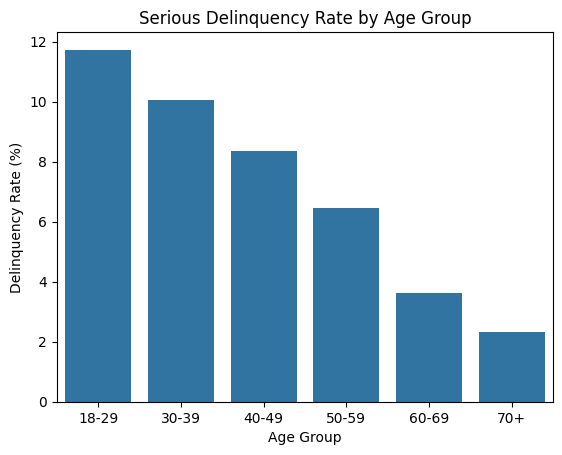

In [39]:
sns.barplot(
    data=age_analysis,
    x="Age_Group",
    y="delinquency_rate"

 ) 
plt.title("Serious Delinquency Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Delinquency Rate (%)")
plt.show()



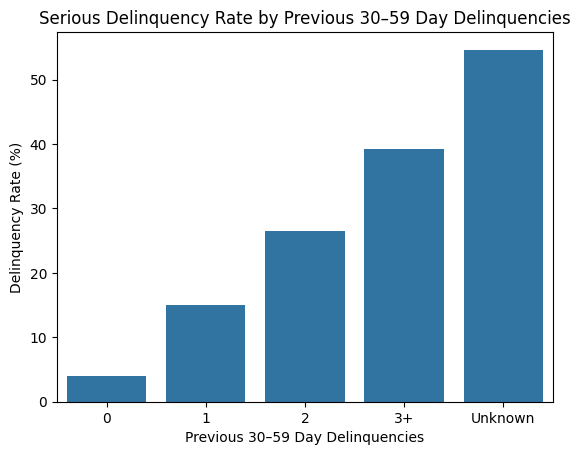

In [40]:
sns.barplot(
    data = late30_analysis ,
    x= "Late_30_59_Group" ,
    y="delinquency_rate"
)
plt.title("Serious Delinquency Rate by Previous 30–59 Day Delinquencies")
plt.xlabel("Previous 30–59 Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

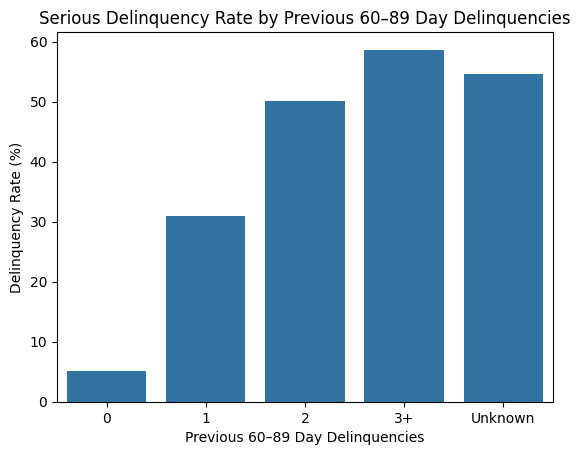

In [41]:
sns.barplot(
    data=late60_analysis,
    x="Late_60_89_Group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Previous 60–89 Day Delinquencies")
plt.xlabel("Previous 60–89 Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

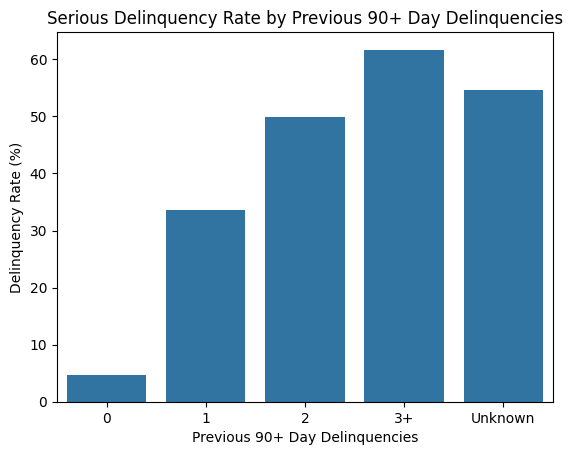

In [42]:
sns.barplot(
    data=late90_analysis,
    x="Late_90Plus_Group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Previous 90+ Day Delinquencies")
plt.xlabel("Previous 90+ Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

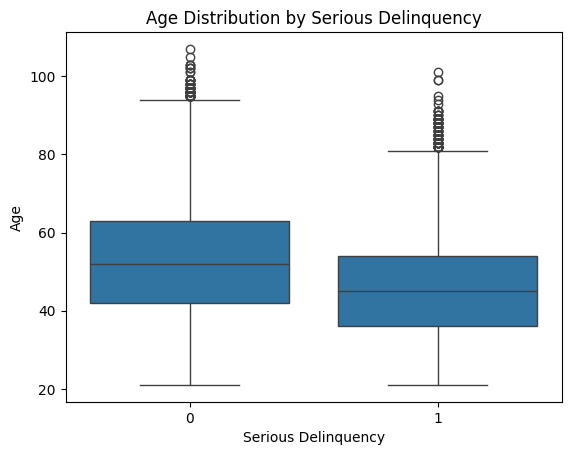

In [43]:
sns.boxplot(
    data=df_clean,
    x="SeriousDlqin2yrs",
    y="age"
)

plt.title("Age Distribution by Serious Delinquency")
plt.xlabel("Serious Delinquency")
plt.ylabel("Age")
plt.show()

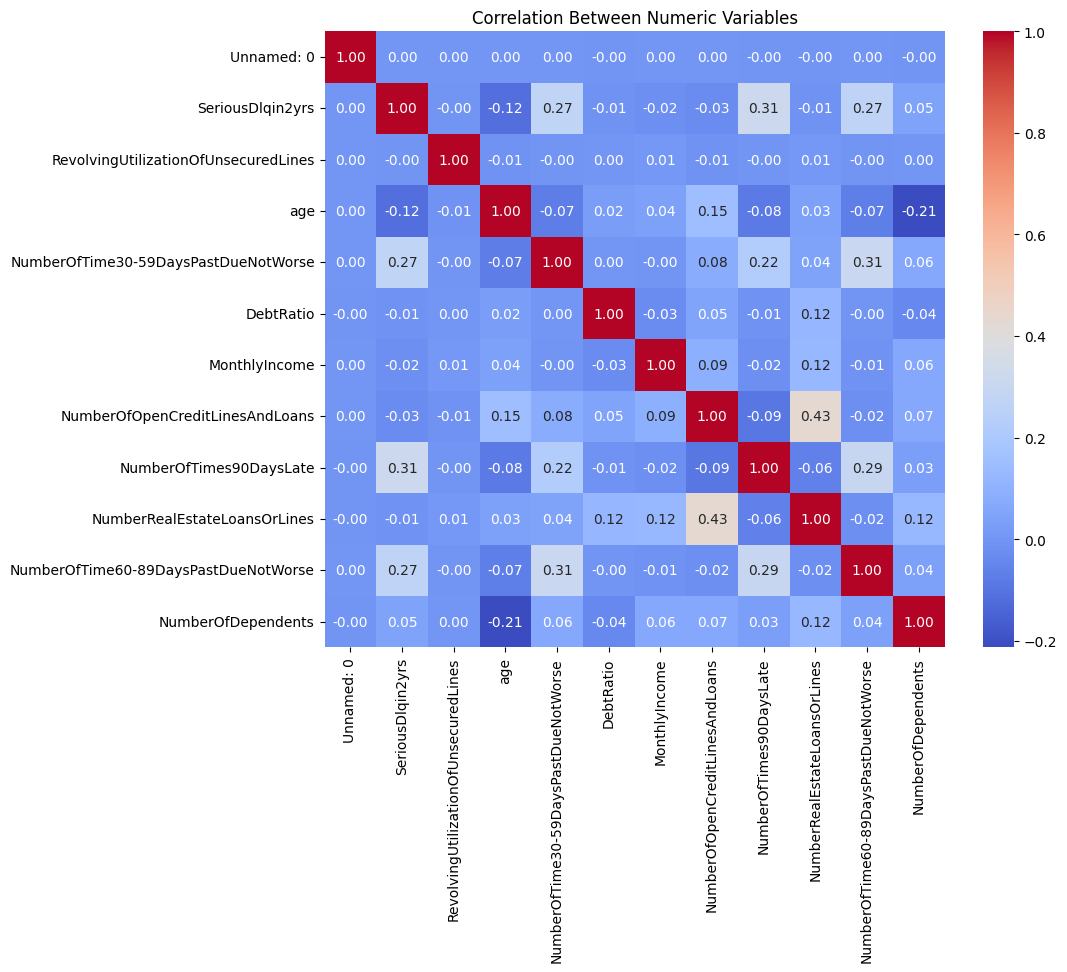

In [44]:
corr = df_clean.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Between Numeric Variables")
plt.show()


## 7. Business Insights

- Around **6.7% of borrowers** were seriously delinquent within the next 2 years.

- The **18–29 age group** had the highest delinquency rate at around **11.7%**.

- Delinquency rates increased as borrowers had **more previous late payments**.

- Borrowers with **3+ previous 90-day late payments** had the highest delinquency rate at around **61.7%**.

- Overall, borrowers with a history of late payments were more likely to have serious delinquency in this dataset.

## 8. Business Recommendations

- Pay more attention to borrowers who have **multiple previous late payments**.

- Give closer monitoring to borrowers with **3+ previous 90-day late payments**.

- Use early reminders or follow-ups for borrowers who repeatedly miss payments.

- Keep an eye on younger borrower groups since they showed higher delinquency rates in this dataset.